## Loading data

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path().resolve().parent

rfm = pd.read_csv(BASE_DIR / "data/processed/rfm_segments.csv")

rfm.head()

,customer_unique_id,frequency,monetary,recency,R_score,F_score,M_score,RFM_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,112,4,1,3,413,Recent
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,115,3,1,1,311,Recent
2,0000f46a3911fa3c0805444483337064,1,86.22,537,1,1,2,112,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,321,2,1,1,211,Lost
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,288,2,1,4,214,Lost


In [2]:
features = rfm[["recency", "frequency", "monetary"]]

# Initial K-Means Clustering

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

## Determining Optimal Number of Clusters

- The Elbow Method is used to evaluate clustering performance across different values of K.
- Inertia measures the compactness of clusters by calculating how far data points are from their assigned cluster centers. Lower inertia indicates tighter and more cohesive clusters.
- The optimal K is selected by identifying the point where inertia reduction begins to slow down significantly.

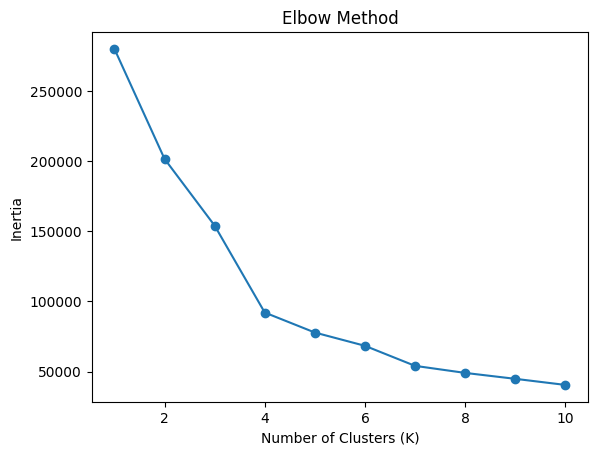

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm["cluster"] = kmeans.fit_predict(scaled_features)

In [6]:
rfm.groupby("cluster")[["recency", "frequency", "monetary"]].mean()

,recency,frequency,monetary
cluster,,,
0,239.329616,1.012805,1160.271400
1,128.595665,1.000000,134.414822
2,220.443723,2.114358,289.680253
3,388.118298,1.000000,133.336830


### Key Observations

- Cluster 0 contains customers with higher spending behavior.
- Cluster 1 represents active but low-spending customers.
- Cluster 2 shows stronger repeat purchase behavior compared to other segments.
- Cluster 3 contains inactive low-value customers with high recency and low spending.

## Cluster Visualization

<Axes: xlabel='recency', ylabel='monetary'>

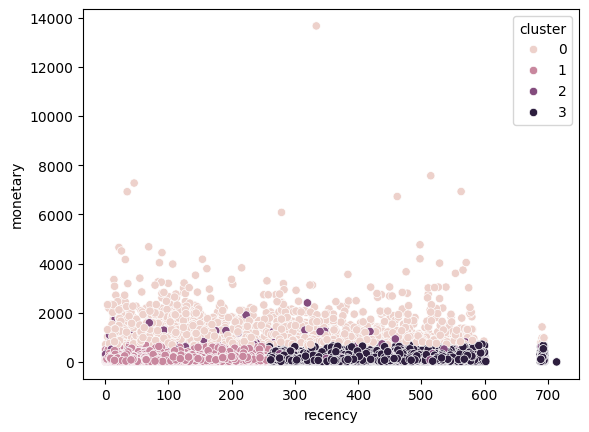

In [7]:
import seaborn as sns

sns.scatterplot(
    data=rfm,
    x="recency",
    y="monetary",
    hue="cluster"
)

<Axes: xlabel='frequency', ylabel='monetary'>

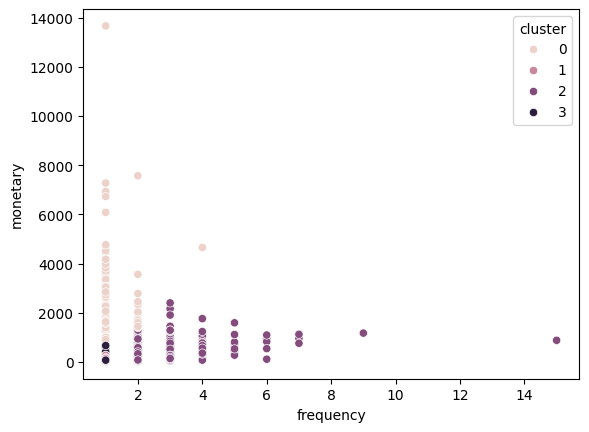

In [8]:
import seaborn as sns

sns.scatterplot(
    data=rfm,
    x="frequency",
    y="monetary",
    hue="cluster"
)

### Initial Clustering Observations

- Customer frequency showed very limited variation, with most customers making only a single purchase.
- Monetary values were highly skewed due to a small number of high-spending customers.
- One cluster became dominated by customers with extremely high monetary values, reducing the influence of recency and frequency during clustering.
- Significant overlap between clusters was observed in the scatter plot, indicating that the raw feature distributions were affecting cluster separation quality.

These observations suggested that additional preprocessing was required before applying K-Means more effectively. To reduce the impact of skewed distributions and extreme values, log transformation was applied to frequency and monetary features in the next step.

# Improving Customer Clustering with Log Transformation

- Initial clustering results showed significant overlap between customer groups due to highly skewed monetary values and outliers.
- Since K-Means relies on distance-based calculations, extreme spending values can dominate cluster formation and reduce the impact of other behavioral features such as frequency and recency.
- To improve cluster quality while preserving customer behavior patterns, log transformation is applied to frequency and monetary features before scaling and clustering.

In [9]:
rfm_log = rfm.copy()

rfm_log["frequency_log"] = np.log1p(rfm_log["frequency"])
rfm_log["monetary_log"] = np.log1p(rfm_log["monetary"])

In [10]:
features = rfm_log[
    ["recency", "frequency_log", "monetary_log"]
]

## Feature Scaling

- Since K-Means relies on distance calculations, features are standardized so that recency, frequency, and monetary contribute equally during clustering.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

## Determining Optimal Number of Clusters

- The Elbow Method is used to evaluate clustering performance across different values of K.
- Inertia measures the compactness of clusters by calculating how far data points are from their assigned cluster centers. Lower inertia indicates tighter and more cohesive clusters.
- The optimal K is selected by identifying the point where inertia reduction begins to slow down significantly.

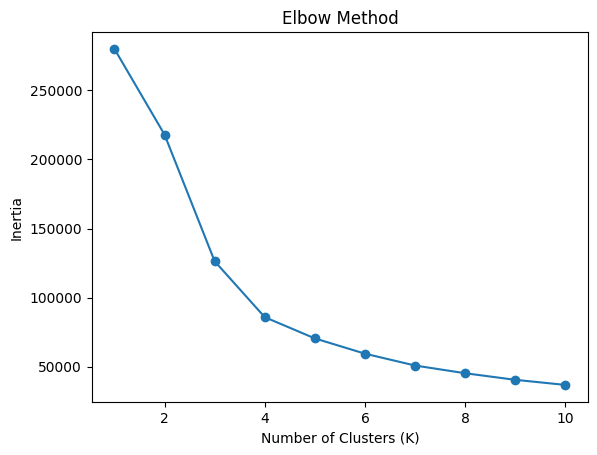

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm_log["cluster"] = kmeans.fit_predict(scaled_features)

In [14]:
rfm_log.groupby("cluster")[
    ["recency", "frequency", "monetary"]
].mean()

,recency,frequency,monetary
cluster,,,
0,176.147981,1.000000,321.591097
1,146.359191,1.000000,69.998466
2,425.006816,1.000000,117.760581
3,220.294538,2.113888,308.588793


### Cluster Profiles

| Cluster | Recency | Avg Frequency | Avg Monetary | Label |
|---------|---------|---------------|--------------|-------|
| 0 | 176 days | 1.00 | BRL 322 | Recent Mid-Spenders |
| 1 | 146 days | 1.00 | BRL 70  | Recent Low-Spenders |
| 2 | 425 days | 1.00 | BRL 118 | Lapsed Low-Value |
| 3 | 220 days | 2.11 | BRL 309 | Repeat Buyers |

Log transformation reduced the influence of monetary outliers and allowed frequency differences to contribute meaningfully to cluster separation.  
Cluster 3 is the only group with avg_frequency > 1 — K-Means isolated repeat buyers as a distinct group without any explicit frequency rule.

## Cluster Visualization

<Axes: xlabel='recency', ylabel='monetary_log'>

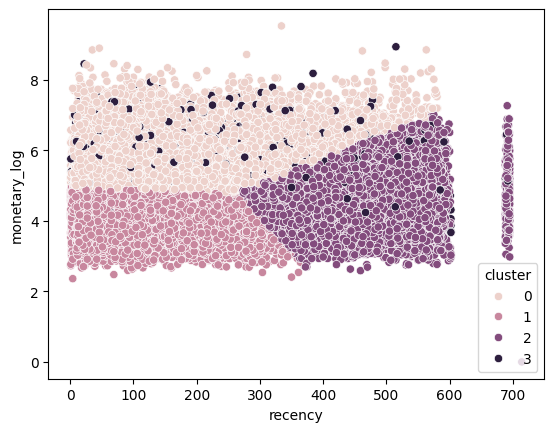

In [15]:
import seaborn as sns

sns.scatterplot(
    data=rfm_log,
    x="recency",
    y="monetary_log",
    hue="cluster"
)

<Axes: xlabel='frequency_log', ylabel='monetary_log'>

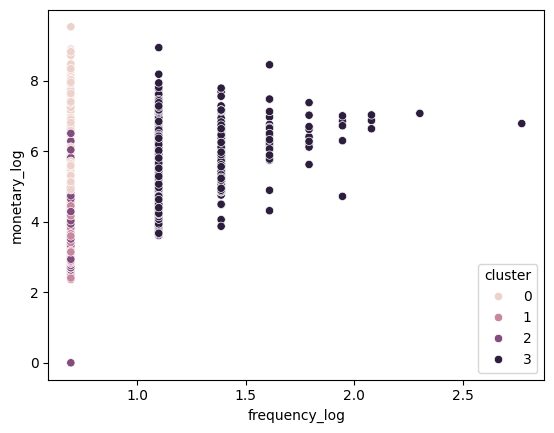

In [16]:
import seaborn as sns

sns.scatterplot(
    data=rfm_log,
    x="frequency_log",
    y="monetary_log",
    hue="cluster"
)

- Customer clusters are visualized using recency and log-transformed monetary values.
- Since clustering was performed using three features (recency, frequency, and monetary), the scatter plot represents only a two-dimensional projection of the clustering space.

### Final Clustering Observations

- Applying log transformation reduced the influence of extreme monetary outliers during clustering.
- Cluster separation became more behaviorally meaningful after balancing the contribution of frequency and monetary features.
- Customer groups were differentiated not only by spending amount, but also by engagement patterns such as repeat purchasing behavior and inactivity.
- Most customers in the dataset were one-time purchasers, which naturally limited the diversity of customer segments.
- Repeat customers formed a distinct cluster with relatively higher purchase frequency and moderate spending behavior.
- Inactive low-value customers were successfully separated based on high recency values and low monetary contribution.

Overall, the transformed clustering approach produced more interpretable and business-relevant customer segments compared to clustering on raw RFM features.

# Comparing Rule-Based Segmentation and K-Means Clustering

Two customer segmentation approaches were developed in this project:

1. Business-driven RFM segmentation using predefined rules based on Recency, Frequency, and Monetary scores.
2. Data-driven K-Means clustering using customer behavioral features.

This comparison evaluates how closely the machine learning generated clusters align with manually defined business segments and helps assess whether both approaches capture similar customer behavior patterns.

In [17]:
cluster_segment = pd.crosstab(
    rfm_log["cluster"],
    rfm_log["segment"]
)

cluster_segment

segment,At Risk,Average,High Value,Lost,Loyal,Recent
cluster,,,,,,
0,4572,2481,8745,2483,4645,4618
1,4321,2201,13197,2205,7034,7059
2,13043,6978,0,6975,0,0
3,1252,0,1549,0,0,0


## Cluster Composition Analysis

Raw customer counts provide an initial view of segment distribution within each cluster.

To better understand cluster characteristics, segment proportions are calculated. This allows us to identify which business-defined customer segments dominate each machine learning cluster.

In [18]:
cluster_segment_pct = pd.crosstab(
    rfm_log["cluster"],
    rfm_log["segment"],
    normalize="index"
) * 100

cluster_segment_pct.round(2)

segment,At Risk,Average,High Value,Lost,Loyal,Recent
cluster,,,,,,
0,16.60,9.01,31.75,9.01,16.86,16.77
1,12.00,6.11,36.64,6.12,19.53,19.60
2,48.31,25.85,0.00,25.84,0.00,0.00
3,44.70,0.00,55.30,0.00,0.00,0.00


### Comparison: K-Means vs Rule-Based Segmentation

**Where they agree:**
- Cluster 2 (Lapsed Low-Value) maps entirely to At Risk, Average, and Lost — zero overlap with any active segment. Both methods agree on who is inactive.

**Where they diverge:**
- Cluster 3 (Repeat Buyers) contains 55% High Value and 45% At Risk customers.
  Rule-based splits these by recency; K-Means keeps them together by purchase frequency. A customer who bought twice but hasn't purchased in 8 months is "At Risk" in the rule-based view but a "Repeat Buyer" in the K-Means view — both are valid, they answer different questions.

- Clusters 0 and 1 are both recent single-purchase customers, separated only by monetary spend. Rule-based assigns them identically (Recent or Loyal based on F_score alone); K-Means distinguishes them by spend level.

**Business implication:**
The two approaches are complementary. Rule-based segments are interpretable and directly actionable (e.g. send a win-back campaign to At Risk). K-Means adds a behavioral layer — particularly useful for identifying repeat buyers as a distinct group regardless of their recency status.

## Visual Comparison of Segments and Clusters

A heatmap is used to visualize the relationship between rule-based RFM segments and K-Means clusters.

Higher values indicate stronger alignment between a cluster and a particular customer segment. This helps evaluate whether the clustering algorithm independently discovered similar customer groupings.

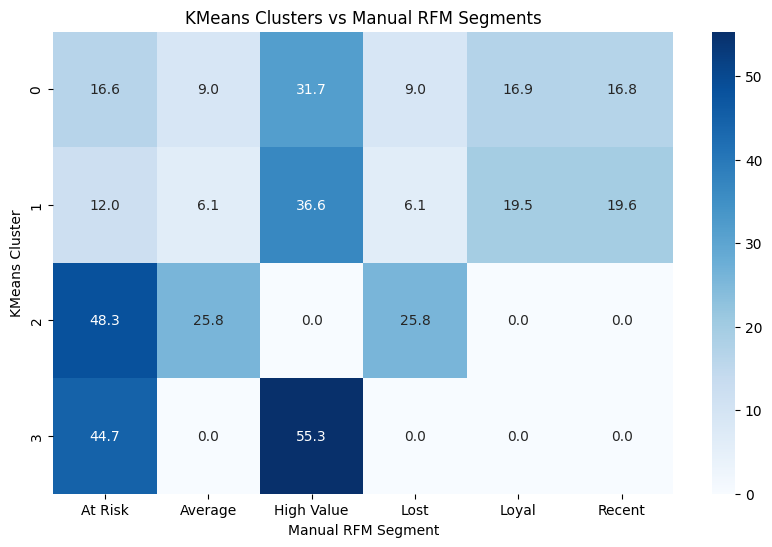

In [19]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_segment_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("KMeans Clusters vs Manual RFM Segments")
plt.xlabel("Manual RFM Segment")
plt.ylabel("KMeans Cluster")

plt.show()